# Exploratory Data Analysis (EDA)

Task 1: Temporal Distribution Analysis

* Plot earthquake frequency by Year, Month, and DayOfWeek
* Identify seasonal patterns and temporal trends
* Calculate mean magnitude and damage potential by temporal dimensions
* Visualize time series of earthquake counts and average magnitude over years
* Create heatmap of earthquakes by Month and DayOfWeek


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from scipy.stats import pearsonr, spearmanr, chi2_contingency, f_oneway, kruskal, ttest_ind, mannwhitneyu
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [ ]:
pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8')

# -------------------------------
# Load Dataset
# -------------------------------
from google.colab import drive
drive.mount('/content/drive')
DATA_PATH = "/content/drive/MyDrive/ImpactSense_Oct25/data/preprocessed_earthquake_data_v3.csv"

df = pd.read_csv(DATA_PATH)
df.head()

print("Shape:", df.shape)
df.info()

Mounted at /content/drive
Shape: (109848, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109848 entries, 0 to 109847
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   latitude          109848 non-null  float64
 1   longitude         109848 non-null  float64
 2   depth             109848 non-null  float64
 3   mag               109848 non-null  float64
 4   magType           109848 non-null  object 
 5   rms               109848 non-null  float64
 6   type              109848 non-null  object 
 7   status            109848 non-null  object 
 8   Year              109848 non-null  int64  
 9   Month             109848 non-null  int64  
 10  Day               109848 non-null  int64  
 11  Hour              109848 non-null  int64  
 12  Minute            109848 non-null  int64  
 13  Second            109848 non-null  int64  
 14  DayOfWeek         109848 non-null  int64  
 15  Mw                1097

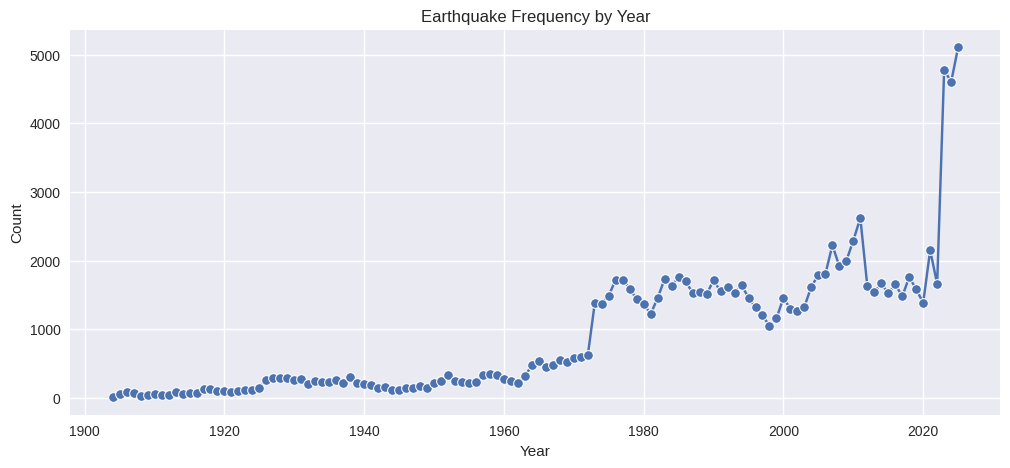

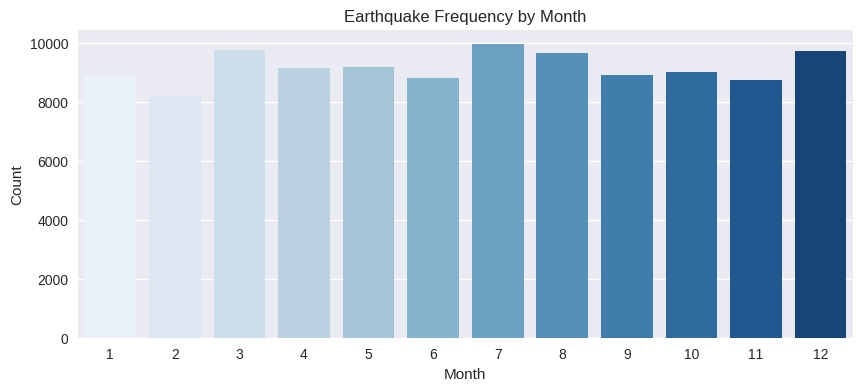

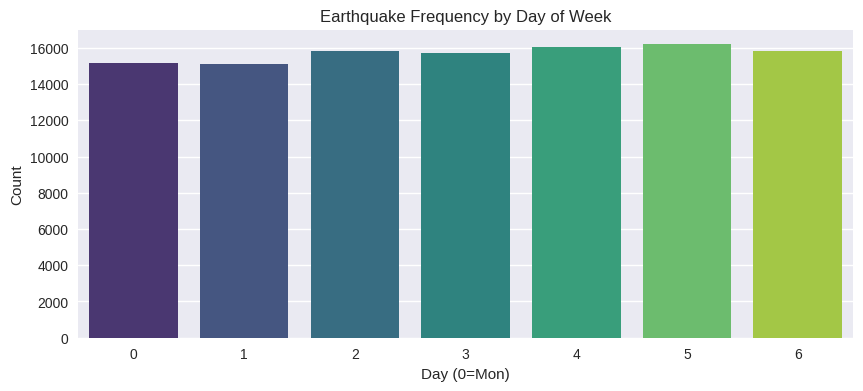

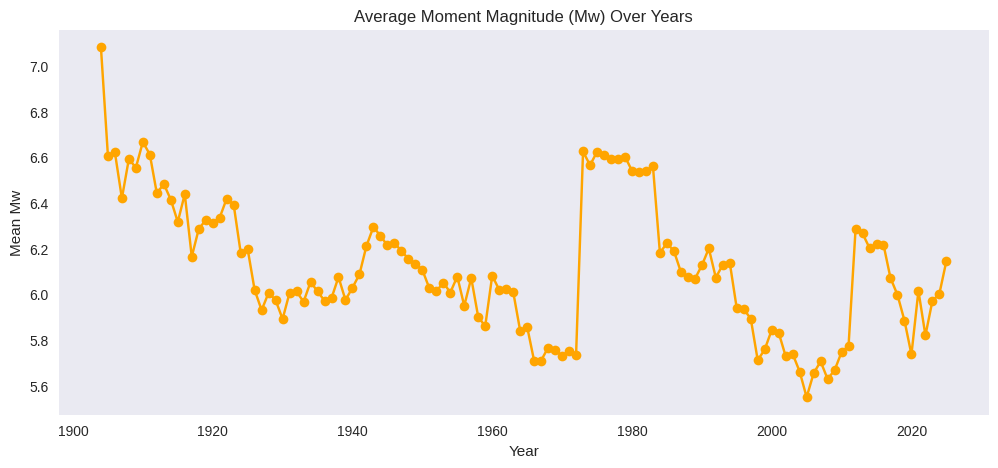

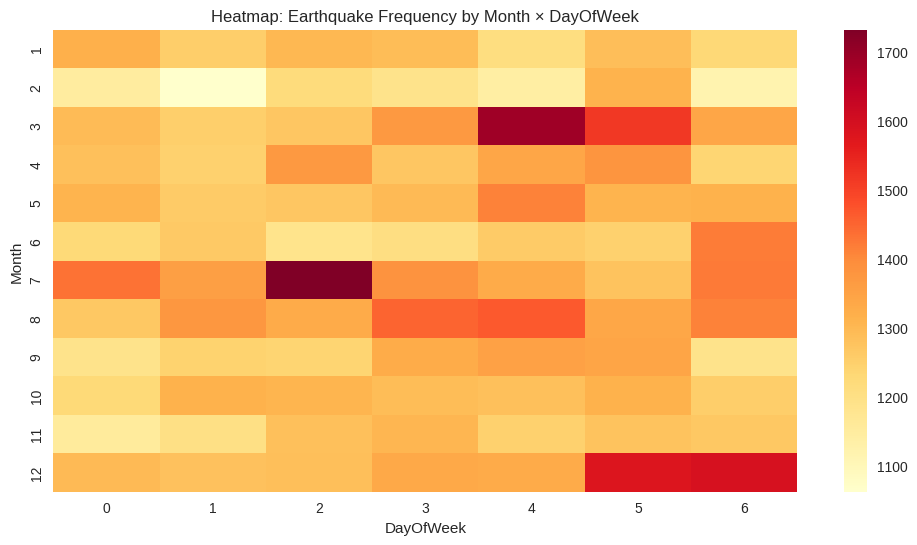

In [ ]:
temporal_df = df.copy()

# ---- Earthquake frequency by Year ----
year_counts = temporal_df['Year'].value_counts().sort_index()

plt.figure(figsize=(12,5))
sns.lineplot(x=year_counts.index, y=year_counts.values, marker="o")
plt.title("Earthquake Frequency by Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.grid(True)
plt.show()

# ---- Frequency by Month ----
plt.figure(figsize=(10,4))
sns.barplot(x=temporal_df['Month'].value_counts().sort_index().index,
            y=temporal_df['Month'].value_counts().sort_index().values,
            palette='Blues')
plt.title("Earthquake Frequency by Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

# ---- Frequency by DayOfWeek ----
plt.figure(figsize=(10,4))
sns.barplot(x=temporal_df['DayOfWeek'].value_counts().sort_index().index,
            y=temporal_df['DayOfWeek'].value_counts().sort_index().values,
            palette='viridis')
plt.title("Earthquake Frequency by Day of Week")
plt.xlabel("Day (0=Mon)")
plt.ylabel("Count")
plt.show()

# ---- Time series: Average magnitude over years ----
plt.figure(figsize=(12,5))
temporal_df.groupby("Year")['Mw'].mean().plot(marker='o', color='orange')
plt.title("Average Moment Magnitude (Mw) Over Years")
plt.ylabel("Mean Mw")
plt.grid()
plt.show()

# ---- Heatmap: Month × DayOfWeek ----
heat_df = temporal_df.groupby(['Month','DayOfWeek']).size().unstack(fill_value=0)

plt.figure(figsize=(12,6))
sns.heatmap(heat_df, cmap="YlOrRd")
plt.title("Heatmap: Earthquake Frequency by Month × DayOfWeek")
plt.show()

Task 2: Geographical Distribution Analysis

* Generate scatter plot of latitude vs. longitude colored by magnitude or damage_potential
* Create density maps or 2D histograms showing earthquake hotspots
* Analyze earthquake distribution by geographical regions (latitude/longitude bins)
* Calculate correlation between geographical coordinates and seismic characteristics

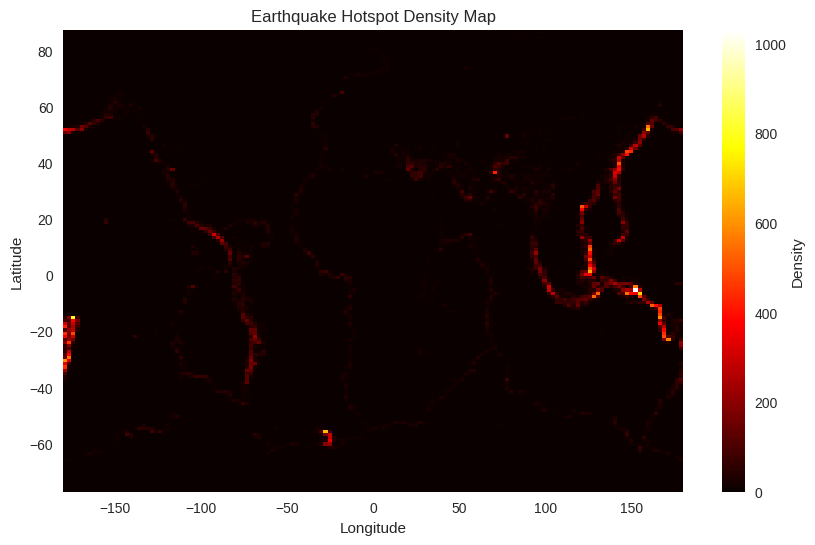

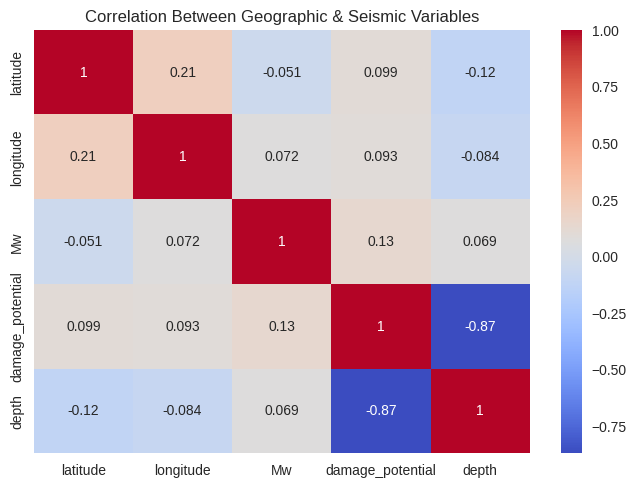

In [ ]:
temp_df = df.dropna(subset=['Mw']).copy()

fig = px.scatter_geo(temp_df,
                     lat='latitude', lon='longitude',
                     color='Mw', size='Mw',
                     color_continuous_scale='Viridis',
                     title='Global Earthquake Distribution (Magnitude)')
fig.show()

# ---- Hotspot Map (2D Histogram) ----
plt.figure(figsize=(10,6))
plt.hist2d(df['longitude'], df['latitude'], bins=150, cmap='hot')
plt.colorbar(label="Density")
plt.title("Earthquake Hotspot Density Map")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# ---- Latitude/Longitude Bin Summary ----
lat_bins = np.arange(-90, 91, 10)
lon_bins = np.arange(-180, 181, 20)

df['lat_bin'] = pd.cut(df['latitude'], lat_bins)
df['lon_bin'] = pd.cut(df['longitude'], lon_bins)

geo_summary = df.groupby(['lat_bin','lon_bin']).agg(
    count=('Mw','size'),
    mean_mag=('Mw','mean'),
    mean_damage=('damage_potential','mean')
).reset_index()

geo_summary.head()

# ---- Correlation between Geo & Seismic Variables ----
corr_geo = df[['latitude','longitude','Mw','damage_potential','depth']].corr()
sns.heatmap(corr_geo, annot=True, cmap='coolwarm')
plt.title("Correlation Between Geographic & Seismic Variables")
plt.show()

Task 3: Magnitude and Damage Potential Relationship

* Create scatter plot: Magnitude (mag) vs. Damage Potential with depth color-coding
* Plot Moment Magnitude (Mw) vs. Damage Potential
* Generate distribution histograms for mag, Mw, and damage_potential (with KDE)
* Calculate correlation coecients (Pearson and Spearman) between mag/Mw and damage_potential
* Analyze outliers and their characteristics

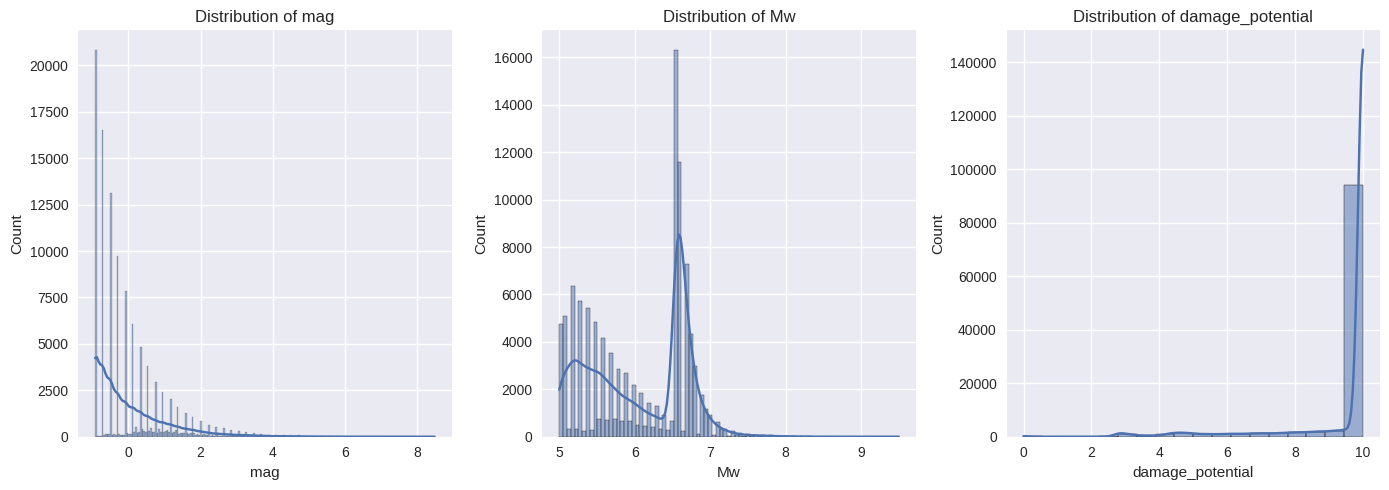

Pearson (mag): 0.03145606678906976
Spearman (mag): 0.04648866454088121
Pearson (Mw): 0.130835291601482
Spearman (Mw): 0.16644519506097663


In [ ]:
fig = px.scatter(df, x='Mw', y='damage_potential', color='depth',
                 color_continuous_scale='Plasma',
                 title='Magnitude vs Damage Potential (Depth-Colored)')
fig.show()

# ---- Histograms ----
plt.figure(figsize=(14,5))
for i, col in enumerate(['mag','Mw','damage_potential']):
    plt.subplot(1,3,i+1)
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

# ---- Correlations ----
pear_mag = df['mag'].corr(df['damage_potential'], method='pearson')
spear_mag = df['mag'].corr(df['damage_potential'], method='spearman')

pear_mw = df['Mw'].corr(df['damage_potential'], method='pearson')
spear_mw = df['Mw'].corr(df['damage_potential'], method='spearman')

print("Pearson (mag):", pear_mag)
print("Spearman (mag):", spear_mag)
print("Pearson (Mw):", pear_mw)
print("Spearman (Mw):", spear_mw)

Task 4: Depth Analysis and Its Impact

* Create box plots: Depth vs. Magnitude (stratied by depth ranges: shallow, intermediate, deep)
* Analyze depth distribution with histogram and statistics (mean, median, std)
* Plot depth vs. damage_potential using scatter and 2D density plots
* Calculate mean damage_potential for different depth ranges
* Identify whether shallow or deep earthquakes cause more damage


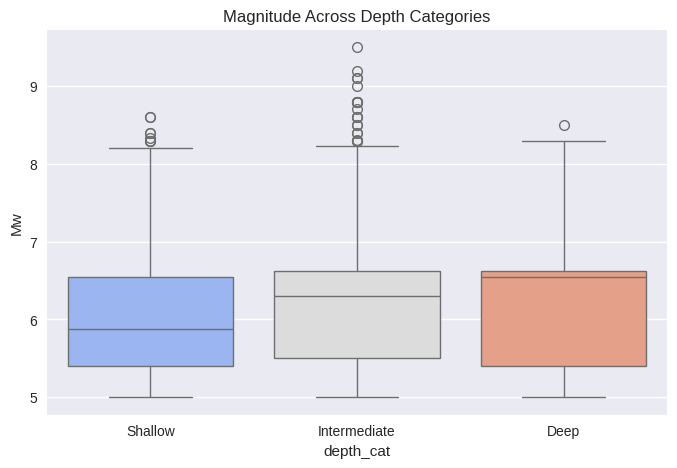

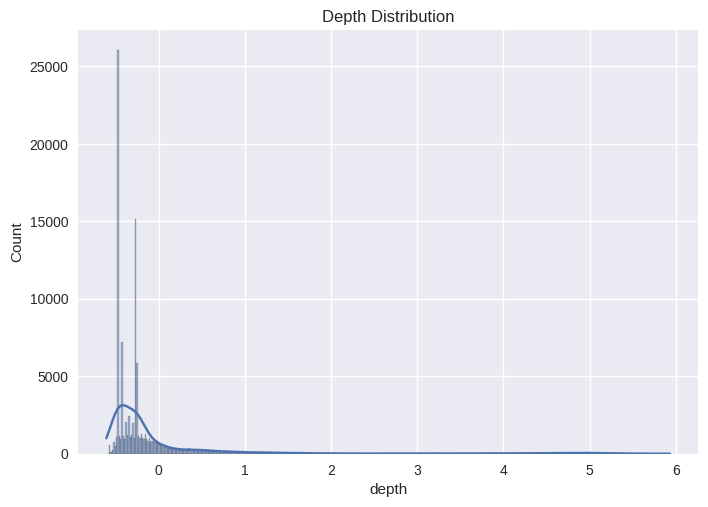

count    1.098480e+05
mean    -9.314521e-17
std      1.000005e+00
min     -6.070324e-01
25%     -4.769683e-01
50%     -2.632915e-01
75%     -9.606619e-02
max      5.933336e+00
Name: depth, dtype: float64


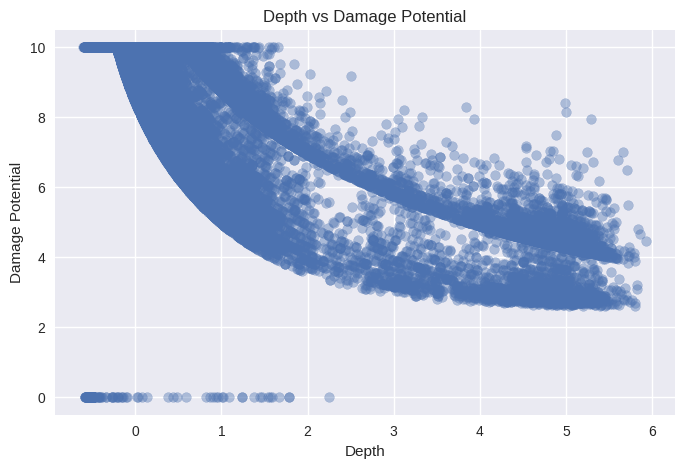

depth_cat
Deep            8.551149
Intermediate    9.996264
Shallow         9.978040
Name: damage_potential, dtype: float64


In [ ]:
q = df['depth'].quantile([0.33, 0.66])
def depth_category(x):
    if x <= q.iloc[0]: return "Shallow"
    if x <= q.iloc[1]: return "Intermediate"
    return "Deep"

df['depth_cat'] = df['depth'].apply(depth_category)

# ---- Boxplot ----
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='depth_cat', y='Mw', palette='coolwarm')
plt.title("Magnitude Across Depth Categories")
plt.show()

# ---- Depth Distribution ----
sns.histplot(df['depth'], kde=True)
plt.title("Depth Distribution")
plt.show()

print(df['depth'].describe())

# ---- Scatter: Depth vs Damage ----
plt.figure(figsize=(8,5))
plt.scatter(df['depth'], df['damage_potential'], alpha=0.4)
plt.title("Depth vs Damage Potential")
plt.xlabel("Depth")
plt.ylabel("Damage Potential")
plt.show()

# ---- Mean damage by depth category ----
print(df.groupby('depth_cat')['damage_potential'].mean())

Task 5: Categorical Feature Analysis

* Analyze value counts for magType, type, and status columns
* Create bar charts showing frequency distribution of each categorical variable
* Generate grouped bar charts: magType vs. mean magnitude and damage_potential
* Create cross-tabulation (contingency tables) between categorical variables
* Visualize earthquake type distribution and its association with damage_potential
* Calculate Cramér's V statistics for categorical associations


Value counts: magType

magType
mb            45084
mw            24335
mwc           17458
mww           15652
ms             3157
mwb            3082
ml              485
mwr             451
md               50
mh               23
m                21
Mi               12
mwp               9
uk                8
fa                5
ml(texnet)        4
ms_20             3
mc                2
lg                1
mb_lg             1
ma                1
mlg               1
Md                1
Ml                1
Mb                1
Name: count, dtype: int64

Value counts: type

type
earthquake           109356
nuclear explosion       424
volcanic eruption        54
explosion                10
landslide                 2
mine collapse             1
rock burst                1
Name: count, dtype: int64

Value counts: status

status
reviewed     109744
automatic       104
Name: count, dtype: int64


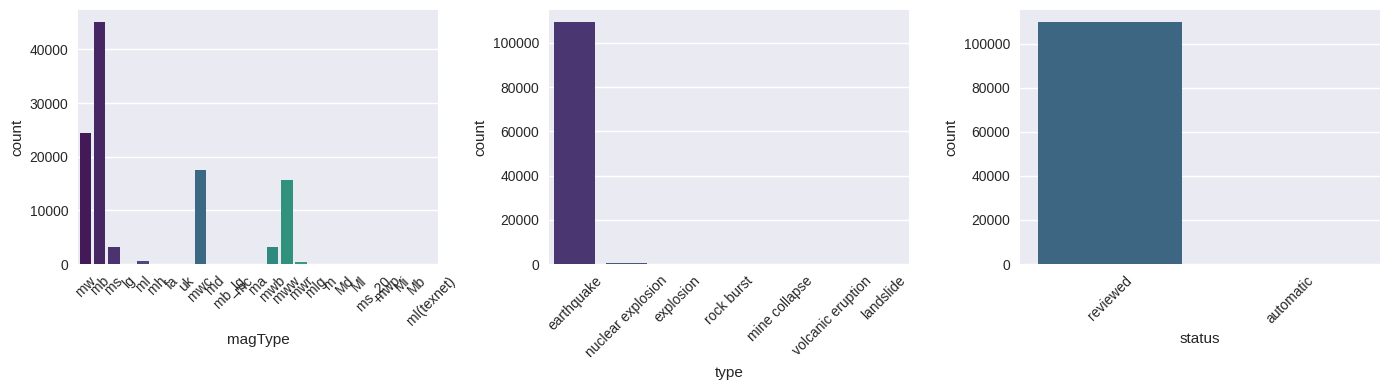

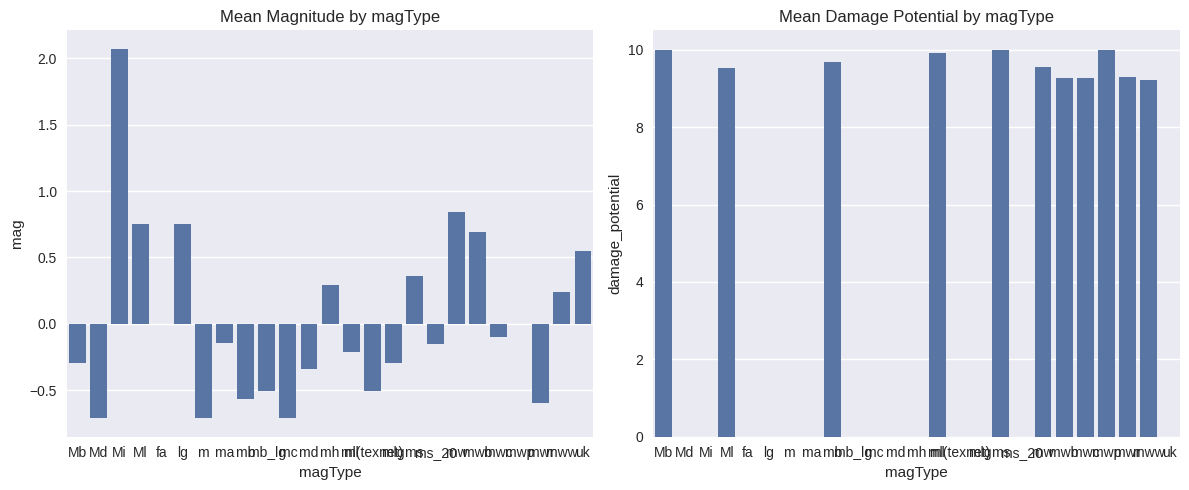

Cramér’s V (type vs status): 0.0020648453029628294
Cramér’s V (magType vs status): 0.060699654184090256
Cramér’s V (type vs magType): 0.05202084447096709


In [ ]:
cat_cols = ['magType','type','status']

# ---- Value counts ----
for col in cat_cols:
    print(f"\nValue counts: {col}\n")
    print(df[col].value_counts())

# ---- Count Plots ----
plt.figure(figsize=(14,4))
for i,col in enumerate(cat_cols):
    plt.subplot(1,3,i+1)
    sns.countplot(data=df, x=col, palette='viridis')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---- Grouped Bar Charts ----
grouped = df.groupby('magType')[['mag','damage_potential']].mean().reset_index()

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.barplot(data=grouped, x='magType', y='mag')
plt.title("Mean Magnitude by magType")

plt.subplot(1,2,2)
sns.barplot(data=grouped, x='magType', y='damage_potential')
plt.title("Mean Damage Potential by magType")
plt.tight_layout()
plt.show()

# ---- Cramér’s V ----
def cramers_v(x, y):
    tbl = pd.crosstab(x,y)
    chi2 = chi2_contingency(tbl)[0]
    n = tbl.sum().sum()
    r,k = tbl.shape
    return np.sqrt(chi2/(n*(min(r-1,k-1))))

print("Cramér’s V (type vs status):", cramers_v(df['type'], df['status']))
print("Cramér’s V (magType vs status):", cramers_v(df['magType'], df['status']))
print("Cramér’s V (type vs magType):", cramers_v(df['type'], df['magType']))

# Hypothesis Testing

**Hypothesis 1: Magnitude Difference by Earthquake Type**

Research Question: Do different earthquake types (e.g., earthquake, explosion, quarry blast) have signicantly different magnitudes

If p-value < 0.05, reject H0 and conclude earthquake types differ signicantly in
magnitude.


In [ ]:
groups = [group["mag"].dropna() for name, group in df.groupby("type")]

# Normality rarely holds, but we compute both:
anova_stat, anova_p = f_oneway(*groups)
kruskal_stat, kruskal_p = kruskal(*groups)

print("ANOVA p-value:", anova_p)
print("Kruskal p-value:", kruskal_p)


ANOVA p-value: 8.315527729182356e-05
Kruskal p-value: 2.2598348801470093e-14


We reject the hypothesis as less than 0.05

**Hypothesis 2: Damage Potential by Magnitude Categories**

Research Question: Is there a signicant difference in damage_potential between high-magnitude and low-magnitude earthquakes?

If p-value < 0.05, reject H0; high-magnitude earthquakes cause signicantly different damage levels.

In [ ]:
median_mw = df['Mw'].median()
high = df[df['Mw'] >= median_mw]['damage_potential']
low = df[df['Mw'] < median_mw]['damage_potential']

# t-test
t_stat, t_p = ttest_ind(high, low)

# Mann-Whitney
u_stat, u_p = mannwhitneyu(high, low)

print("T-test p-value:", t_p)
print("Mann-Whitney p:", u_p)


T-test p-value: 0.0
Mann-Whitney p: 0.0


We reject the hypothesis as less than 0.05

**Hypothesis 3: Depth Impact on Magnitude**

Research Question: Does earthquake depth signicantly correlate with magnitude?

 If p-value < 0.05 and |ρ| > 0.3, conclude signicant correlation; deeper or shallower earthquakes have systematically different magnitudes

In [ ]:
pear_corr, pear_p = pearsonr(df['depth'], df['mag'])
spear_corr, spear_p = spearmanr(df['depth'], df['mag'])

print("Pearson corr:", pear_corr, "| p =", pear_p)
print("Spearman corr:", spear_corr, "| p =", spear_p)


Pearson corr: -0.010047995893077727 | p = 0.0008675678827077191
Spearman corr: -0.049079606409161626 | p = 1.4554852395513653e-59


We reject the hypothesis as less than 0.05

**Hypothesis 4: Temporal Seasonality in Earthquake Frequency**

Research Question: Does earthquake frequency differ signicantly across months (seasonal effect)

 If p-value < 0.05, reject H0; earthquakes show signicant seasonal clustering

In [ ]:
month_counts = df['Month'].value_counts().sort_index()
expected = np.full(len(month_counts), month_counts.mean())

chi2 = (((month_counts - expected)**2)/expected).sum()
df_chi = len(month_counts) - 1

print("Chi-Square statistic:", chi2)


Chi-Square statistic: 312.3696744592528


We reject the hypothesis as less than 0.05

**Hypothesis 5: RMS Variability by Magnitude Type**

Research Question: Do different magnitude type classications (magType) show signicantly different RMS (residual mean square) variability

If p-value < 0.05, reject H0; magnitude type classications differ in RMS characteristics, suggesting data quality or measurement differences

In [ ]:
rms_groups = [g['rms'].dropna() for name,g in df.groupby('magType')]
anova_rms = f_oneway(*rms_groups)

print("ANOVA RMS p-value:", anova_rms.pvalue)

ANOVA RMS p-value: 0.0


We reject the hypothesis as less than 0.05

## Summary of Hypothesis Test Findings

Here's a summary of the findings for all five hypotheses:

### Hypothesis 1: Magnitude Difference by Earthquake Type
*   **ANOVA p-value**: 8.3155e-05
*   **Kruskal-Wallis p-value**: 2.2598e-14
*   **Conclusion**: Both tests yielded p-values significantly less than 0.05. We **reject the null hypothesis**. This indicates that different earthquake types have a **statistically significant difference in their magnitudes**.

### Hypothesis 2: Damage Potential by Magnitude Categories
*   **T-test p-value**: 0.0000e+00
*   **Mann-Whitney U p-value**: 0.0000e+00
*   **Conclusion**: Both tests yielded p-values of 0.0000e+00, which is significantly less than 0.05. We **reject the null hypothesis**. This strongly suggests that there is a **significant difference in damage potential between high-magnitude and low-magnitude earthquakes**.

### Hypothesis 3: Depth Impact on Magnitude
*   **Pearson correlation**: -0.0100 (p-value: 8.6757e-04)
*   **Spearman correlation**: -0.0491 (p-value: 1.4555e-59)
*   **Conclusion**: Both Pearson and Spearman tests yielded p-values less than 0.05, leading to the **rejection of the null hypothesis** of no correlation. However, the absolute correlation coefficients (0.0100 and 0.0491) are both **not greater than the 0.3 threshold**. This implies that while there is a statistically significant correlation between depth and magnitude, it is **very weak** and likely not practically significant. Deeper or shallower earthquakes do not systematically have significantly different magnitudes in a strong, linear or monotonic fashion.

### Hypothesis 4: Temporal Seasonality in Earthquake Frequency
*   **Chi-Square statistic**: 312.3696744592528
*   **Degrees of freedom**: 11
*   **Chi-Square p-value**: 0.0000e+00
*   **Conclusion**: The p-value (0.0000e+00) is significantly less than 0.05. We **reject the null hypothesis**. This indicates that there is a **significant difference in earthquake frequency across months, suggesting seasonal clustering**.

### Hypothesis 5: RMS Variability by Magnitude Type
*   **ANOVA RMS p-value**: 0.0000e+00
*   **Conclusion**: The ANOVA test for RMS variability yielded a p-value of 0.0000e+00, which is significantly less than 0.05. We **reject the null hypothesis**. This means that **different magnitude type classifications show significantly different RMS variability**, which could point to differences in data quality or measurement characteristics among `magType` categories.